<a href="https://colab.research.google.com/github/koherrera97/kevin_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from google.colab import files
uploaded = files.upload ()

Saving bread_basket.csv to bread_basket (1).csv


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [29]:
df = pd.read_csv("bread_basket.csv")
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [32]:
df.describe(include="all")

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

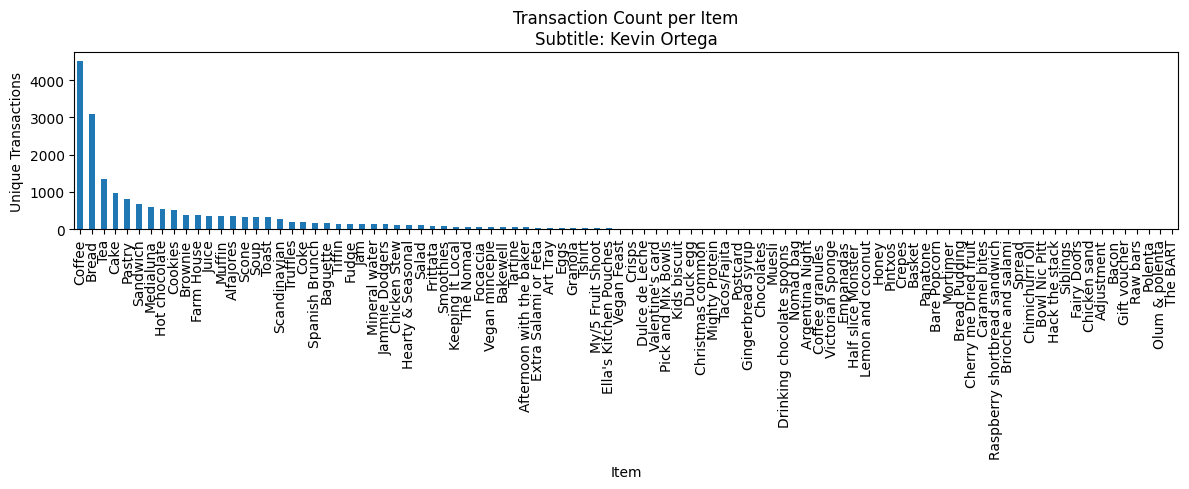

In [62]:
# c) Bar plot of transaction counts per item

subtitle = "Kevin Ortega"
item_counts = (df.groupby("item")["transaction"]
                 .nunique()
                 .sort_values(ascending=False))

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [75]:
items_of_interest = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]

item_counts = (df.groupby("item")["transaction"]
                 .nunique()
                 .sort_values(ascending=False))

filtered_counts = item_counts[item_counts.index.isin(items_of_interest)]

print(filtered_counts.to_string())

item
Coffee          4528
Tea             1350
Juice            365
Alfajores        344
Chicken Stew     123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [78]:
basket = df.groupby("transaction")["item"].apply(list).reset_index()

te = TransactionEncoder()
te_array = te.fit_transform(basket["item"])
basket_df = pd.DataFrame(te_array, columns = te.columns_)

print("Shape of one-hot table:", basket_df.shape)
print (basket_df.head())

frequent_itemsets = fpgrowth(basket_df, min_support=0.02, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)

print(f"\nFound {len(frequent_itemsets)} frequent itemsets")
print(frequent_itemsets.head(20))



Shape of one-hot table: (9465, 94)
   Adjustment  Afternoon with the baker  ...  Vegan mincepie  Victorian Sponge
0       False                     False  ...           False             False
1       False                     False  ...           False             False
2       False                     False  ...           False             False
3       False                     False  ...           False             False
4       False                     False  ...           False             False

[5 rows x 94 columns]

Found 33 frequent itemsets
     support             itemsets
5   0.478394             (Coffee)
0   0.327205              (Bread)
8   0.142631                (Tea)
12  0.103856               (Cake)
19  0.090016      (Coffee, Bread)
6   0.086107             (Pastry)
13  0.071844           (Sandwich)
7   0.061807          (Medialuna)
2   0.058320      (Hot chocolate)
28  0.054728       (Coffee, Cake)
3   0.054411            (Cookies)
25  0.049868        (Tea, Coffee

## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [83]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
rules = rules.sort_values("confidence", ascending=False)

print(f"Found {len(rules)} association rules")
print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].to_string())

Found 13 association rules
        antecedents consequents   support  confidence      lift
10          (Toast)    (Coffee)  0.023666    0.704403  1.472431
5       (Medialuna)    (Coffee)  0.035182    0.569231  1.189878
3          (Pastry)    (Coffee)  0.047544    0.552147  1.154168
12          (Juice)    (Coffee)  0.020602    0.534247  1.116750
4        (Sandwich)    (Coffee)  0.038246    0.532353  1.112792
1            (Cake)    (Coffee)  0.054728    0.526958  1.101515
8         (Cookies)    (Coffee)  0.028209    0.518447  1.083723
6   (Hot chocolate)    (Coffee)  0.029583    0.507246  1.060311
2             (Tea)    (Coffee)  0.049868    0.349630  0.730840
7          (Pastry)     (Bread)  0.029160    0.338650  1.034977
0           (Bread)    (Coffee)  0.090016    0.275105  0.575059
9            (Cake)       (Tea)  0.023772    0.228891  1.604781
11           (Cake)     (Bread)  0.023349    0.224822  0.687097


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

Support: The fraction of all transactions that contain coffee,cake, and bread is 0.054 out of 1.0.

Confidence: Out of the people who bought coffee and cake 52% of people also bought bread.

Lift > 1: Customers who buy coffee and cake are 10 % more likely to also buy bread compared to a random customer. It's a positive association but fairly weak as it is just slightly above 1. The highest percentage is a lift of 1.6 which means that if a person bought cake and tea they are 60% more likely to also buy bread.  

---

